**Cloudy or Sunny day with Markov Chain.**

We call a cloudy day 0 and a sunny day 1. 

![image.png](https://miro.medium.com/max/416/1*frksGjINf5oTjx7WL81U3w.png)

The stationary sunny probability is $p_* = \frac{0.5}{0.5 + 0.1} \approx 0.833$.

In [94]:
import numpy as np
import matplotlib.pyplot as plt

In [95]:
today = 0
N = 10000
p_clear = []
current_p_clear = 0

In [96]:
for i in range(N):
    if today == 0:
        tomorrow = np.random.choice([0, 1], p=[0.5, 0.5])
    elif today == 1:
        tomorrow = np.random.choice([0, 1], p=[0.1, 0.9])
    else:
        raise ValueError("today should be 0, 1, or 2")

    today = tomorrow

    if today == 1:
        current_p_clear += 1
    p_clear.append(current_p_clear / (i + 1))

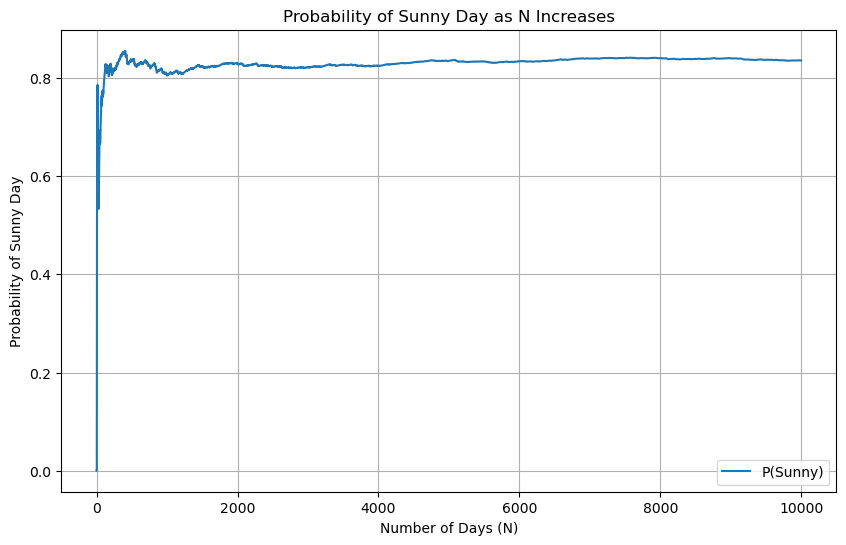

In [97]:
plt.figure(figsize=(10, 6))
plt.plot(range(N), p_clear, label="P(Sunny)")
plt.xlabel("Number of Days (N)")
plt.ylabel("Probability of Sunny Day")
plt.title("Probability of Sunny Day as N Increases")
plt.legend()
plt.grid()
plt.show()

/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_27871/2513365624.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


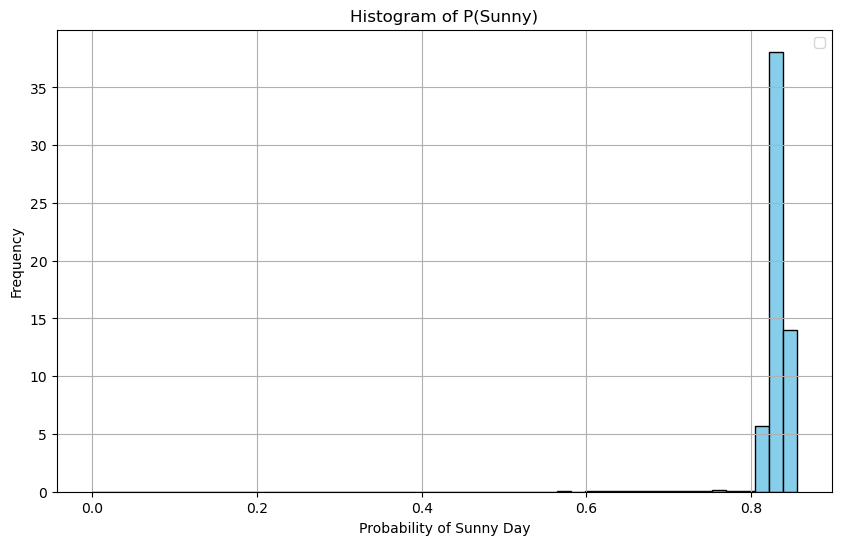

Estimated mean P(Sunny): 0.829640
Standard error: 0.000233


In [98]:
plt.figure(figsize=(10, 6))
plt.hist(p_clear, bins=50, density=True, color='skyblue', edgecolor='black')
plt.xlabel("Probability of Sunny Day")
plt.ylabel("Frequency")
plt.title("Histogram of P(Sunny)")
plt.legend()
plt.grid()
plt.show()

mean_p = np.mean(p_clear)
std_p = np.std(p_clear, ddof=1)
se_p = std_p / np.sqrt(N)

print(f"Estimated mean P(Sunny): {mean_p:.6f}")
print(f"Standard error: {se_p:.6f}")

**OPTIONAL: Finance**

Redo in the new case from finance. The Markovian proces to simulate is rappresented graphically:

![](https://upload.wikimedia.org/wikipedia/commons/thumb/9/95/Finance_Markov_chain_example_state_space.svg/400px-Finance_Markov_chain_example_state_space.svg.png)

Bull = 0, Bear = 1, Stagn= 2.


In [99]:
attual = 0
p_stg = []
p_bull = []
p_bear = []
current_p_stg = 0
current_p_bull = 0
current_p_bear = 0

In [100]:
for i in range(N):
    if attual == 0:
        future = np.random.choice([0, 1, 2], p=[0.9, 0.075, 0.025])
    elif attual == 1:
        future = np.random.choice([0, 1, 2], p=[0.15, 0.8, 0.05])
    elif attual == 2:
        future = np.random.choice([0, 1, 2], p=[0.25, 0.25, 0.5])
    else:
        raise ValueError("attual should be 0, 1, or 2")

    attual = future

    if attual == 0:
        current_p_bull += 1
    elif attual == 1:
        current_p_bear += 1
    elif attual == 2:
        current_p_stg += 1
    else:
        raise ValueError("attual should be 0, 1, or 2")
    
    p_stg.append(current_p_stg / (i + 1))
    p_bull.append(current_p_bull / (i + 1))
    p_bear.append(current_p_bear / (i + 1))

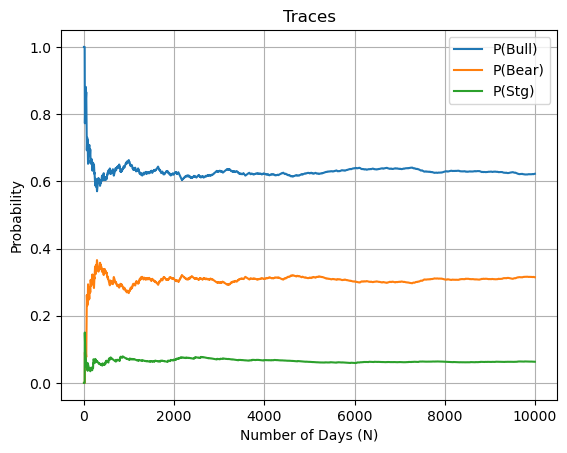

In [101]:
plt.plot(range(N), p_bull, label="P(Bull)")
plt.plot(range(N), p_bear, label="P(Bear)")
plt.plot(range(N), p_stg, label="P(Stg)")
plt.xlabel("Number of Days (N)")
plt.ylabel("Probability")
plt.title("Traces")
plt.legend()
plt.grid()
plt.show()

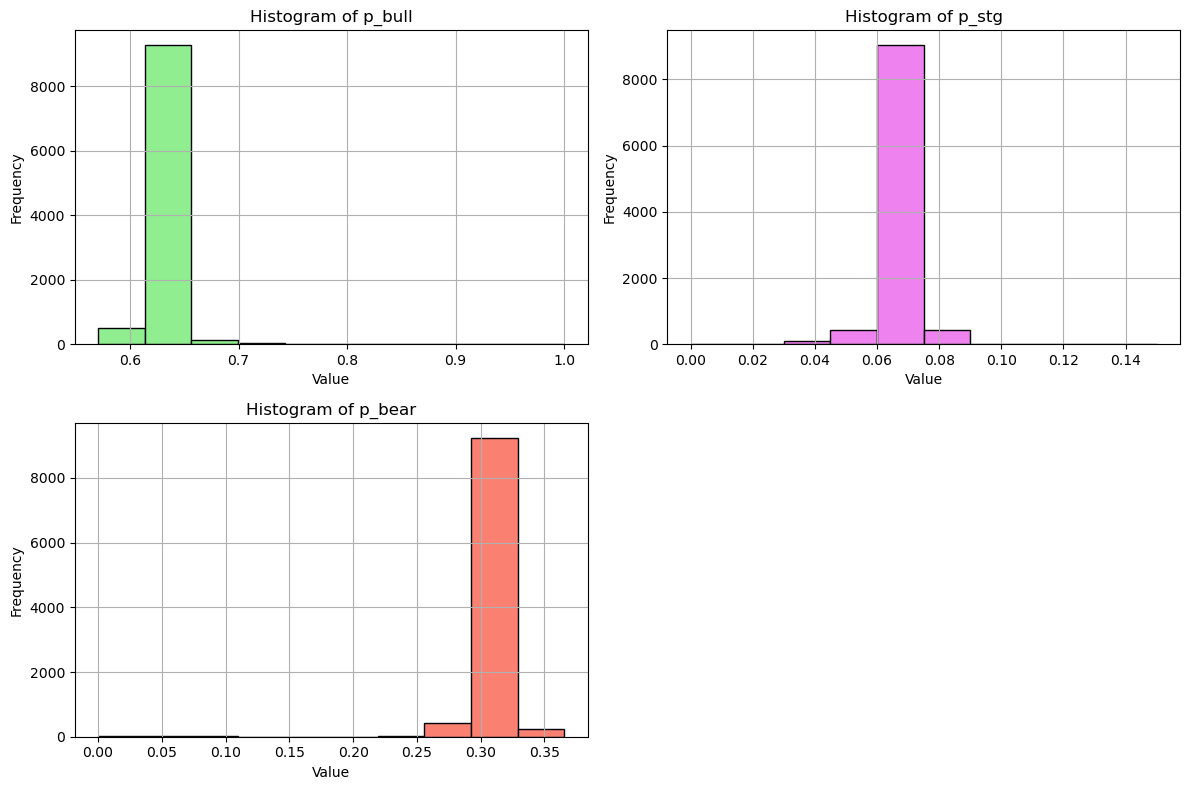

p_bull -> media: 0.629496, deviazione std: 0.023577
p_bear -> media: 0.305661, deviazione std: 0.022224
p_stg  -> media: 0.064843, deviazione std: 0.006200


In [103]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(p_bull, bins=10, color="lightgreen", edgecolor="black")
axes[0, 0].set_title("Histogram of p_bull")
axes[0, 0].set_xlabel("Value")
axes[0, 0].set_ylabel("Frequency")

axes[1, 0].hist(p_bear, bins=10, color="salmon", edgecolor="black")
axes[1, 0].set_title("Histogram of p_bear")
axes[1, 0].set_xlabel("Value")
axes[1, 0].set_ylabel("Frequency")

axes[0, 1].hist(p_stg, bins=10, color="violet", edgecolor="black")
axes[0, 1].set_title("Histogram of p_stg")
axes[0, 1].set_xlabel("Value")
axes[0, 1].set_ylabel("Frequency")

axes[1, 1].axis("off")

for ax in axes.ravel():
    ax.grid(True)

plt.tight_layout()
plt.show()

mean_bull, std_bull = np.mean(p_bull), np.std(p_bull, ddof=1)
mean_bear, std_bear = np.mean(p_bear), np.std(p_bear, ddof=1)
mean_stg, std_stg = np.mean(p_stg), np.std(p_stg, ddof=1)

print(f"p_bull -> media: {mean_bull:.6f}, deviazione std: {std_bull:.6f}")
print(f"p_bear -> media: {mean_bear:.6f}, deviazione std: {std_bear:.6f}")
print(f"p_stg  -> media: {mean_stg:.6f}, deviazione std: {std_stg:.6f}")